# `dijkstra` — Dijkstra 알고리즘 데모

[`algorithms/graph/dijkstra.py`](dijkstra.py) 는 textbook min-heap Dijkstra — priority queue 에서 추출 시 `("visit", u, dist)`, 완화 성공 시 `("relax", u, v, new_dist)` 를 yield 한다.

[`algorithms/graph/trace.py`](trace.py) 의 `@trace` 데코레이터가 `dijkstra.visits` · `dijkstra.path` helper 를 자동 부여한다. 음수 가중치가 없는 그래프에서만 올바르게 동작한다.

In [ ]:
import sys

sys.path.insert(0, '../..')

import core.graph as g
from algorithms.graph.dijkstra import dijkstra

a, b, c, d, e, f = g.vertices('a', 'b', 'c', 'd', 'e', 'f')


def show(graph, start, end):
    """원본 그래프 위에 start→end 최단 경로를 강조."""
    return graph._to_graphviz(highlight=dijkstra.path(graph, start, end))

## 0. textbook 사용법

`dijkstra(g, a)` — raw 이벤트 iterator. `dijkstra.visits(g, a)` 로 추출 순서, `dijkstra.path(g, a, e)` 로 최단 경로.

In [2]:
g0 = g.WeightedGraph[int](kind=g.EdgeKind.DIRECTED)
for u, v, w in [(a, b, 1), (a, c, 4), (b, c, 2), (b, d, 5), (c, e, 1), (d, e, 3)]:
    g0.add_edge(u, v, w)

print('visits:', dijkstra.visits(g0, a))
print('path a→e:', dijkstra.path(g0, a, e))

visits: [Vertex('a'), Vertex('b'), Vertex('c'), Vertex('e'), Vertex('d')]
path a→e: a → 1 → b → 2 → c → 1 → e


## 1. Path — `a -2- b -3- c -1- d`

분기 없는 선형 — 유일한 경로를 그대로 반환.

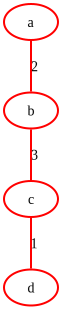

In [3]:
show(g.Graph(a - 2 - b - 3 - c - 1 - d), a, d)

## 2. 경쟁 경로

```
a -1- b
a -4- c
b -2- c
b -5- d
c -1- e
d -3- e
```

`a→e` 후보: `a→b→c→e` = 4, `a→c→e` = 5, `a→b→d→e` = 9. Dijkstra 가 4 를 선택.

visits: [Vertex('a'), Vertex('b'), Vertex('c'), Vertex('e'), Vertex('d')]


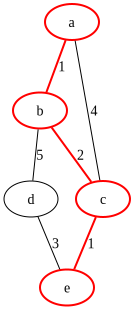

In [4]:
g2 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 1), (a, c, 4), (b, c, 2), (b, d, 5), (c, e, 1), (d, e, 3)]:
    g2.add_edge(u, v, w)

print('visits:', dijkstra.visits(g2, a))
show(g2, a, e)

## 3. 복수 목적지

같은 소스 `a` 에서 `d`, `e` 각각 최단 경로. 이벤트 스트림을 두 번 소비.

In [5]:
print('path a→d:', dijkstra.path(g2, a, d))
print('path a→e:', dijkstra.path(g2, a, e))

path a→d: a - 1 - b - 5 - d
path a→e: a - 1 - b - 2 - c - 1 - e


## 4. Directed — `a → c → b → d`

단방향 그래프. `a→b` 직통(4)보다 `a→c→b`(1+2=3)가 짧다.

visits: [Vertex('a'), Vertex('c'), Vertex('b'), Vertex('d')]


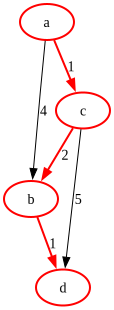

In [6]:
g4 = g.WeightedGraph[int](kind=g.EdgeKind.DIRECTED)
for u, v, w in [(a, b, 4), (a, c, 1), (c, b, 2), (b, d, 1), (c, d, 5)]:
    g4.add_edge(u, v, w)

print('visits:', dijkstra.visits(g4, a))
show(g4, a, d)

## 5. Dense — K4 에 가중치

모든 쌍 연결. `a→d` 직통(7)보다 `a→b→d`(3+1=4)가 짧다.

visits: [Vertex('a'), Vertex('c'), Vertex('b'), Vertex('d')]


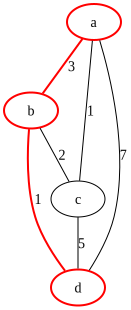

In [7]:
g5 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 3), (a, c, 1), (a, d, 7), (b, c, 2), (b, d, 1), (c, d, 5)]:
    g5.add_edge(u, v, w)

print('visits:', dijkstra.visits(g5, a))
show(g5, a, d)

## 6. 고립 정점 — 경로 없음

`d` 가 `a` 컴포넌트와 단절 → `ValueError`.

In [8]:
g6 = g.WeightedGraph[int]()
g6.add_edge(a, b, 1)
g6.add_vertex(d)

try:
    dijkstra.path(g6, a, d)
except ValueError as exc:
    print(exc)

No path from a to d


## 7. 6-node 복합 그래프

```
a -2- b -5- d
a -6- c     |
b -3- e -1- f
c -8- e
c -4- f
d -7- f
```

`a→f` 최단: `a→b→e→f` = 2+3+1 = 6.

visits: [Vertex('a'), Vertex('b'), Vertex('e'), Vertex('c'), Vertex('f'), Vertex('d')]


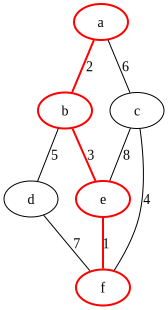

In [9]:
g7 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 2), (a, c, 6), (b, d, 5), (b, e, 3), (c, e, 8), (c, f, 4), (d, f, 7), (e, f, 1)]:
    g7.add_edge(u, v, w)

print('visits:', dijkstra.visits(g7, a))
show(g7, a, f)

## 8. raw 이벤트 스트림

`dijkstra(g, a)` 직접 소비 — `"visit"` / `"relax"` 이벤트 분리 출력.

In [10]:
for event in dijkstra(g7, a):
    match event:
        case ('visit', u, dist):
            print(f'  extract {u}  dist={dist}')
        case ('relax', u, v, new_dist):
            print(f'    relax  {u}→{v}  new_dist={new_dist}')

  extract a  dist=0.0
    relax  a→b  new_dist=2.0
    relax  a→c  new_dist=6.0
  extract b  dist=2.0
    relax  b→d  new_dist=7.0
    relax  b→e  new_dist=5.0
  extract e  dist=5.0
    relax  e→f  new_dist=6.0
  extract c  dist=6.0
  extract f  dist=6.0
  extract d  dist=7.0
